In [1]:
pip install gymnasium torch numpy

Note: you may need to restart the kernel to use updated packages.


In [10]:
# Hyperparameters
GAMMA = 0.99
LR = 3e-4
ENTROPY_BETA = 0.001
EPISODES = 1000


The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


 **Network**

In [11]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

class ActorCritic(nn.Module):

    def __init__(self, state_dim, action_dim):
        super().__init__()

        self.fc1 = nn.Linear(state_dim, 128)

        self.actor = nn.Linear(128, action_dim)
        self.critic = nn.Linear(128, 1)

    def forward(self, x):

        x = F.relu(self.fc1(x))

        action_probs = F.softmax(self.actor(x), dim=-1)
        value = self.critic(x)

        return action_probs, value


**Training loop**

In [15]:
def train():

    env = gym.make("CartPole-v1")

    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    model = ActorCritic(state_dim, action_dim)
    optimizer = optim.Adam(model.parameters(), lr=LR)

    rewards_per_episode = []

    for episode in range(EPISODES):

        state, _ = env.reset()
        done = False
        total_reward = 0

        while not done:

            state_t = torch.FloatTensor(state)

            probs, value = model(state_t)

            dist = torch.distributions.Categorical(probs)
            action = dist.sample()

            next_state, reward, terminated, truncated, _ = env.step(action.item())

            done = terminated or truncated

            next_state_t = torch.FloatTensor(next_state)

            _, next_value = model(next_state_t)

            if done:
                next_value = torch.tensor([0.0])

            delta = reward + GAMMA * next_value - value

            actor_loss = -dist.log_prob(action) * delta.detach()
            critic_loss = delta.pow(2)

            entropy = dist.entropy()

            loss = actor_loss + critic_loss - ENTROPY_BETA * entropy

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            state = next_state
            total_reward += reward

        rewards_per_episode.append(total_reward)

        if episode % 100 == 0:
            print("Episode:", episode, "Reward:", total_reward)

    env.close()

    return rewards_per_episode

Episode: 0 Reward: 14.0
Episode: 100 Reward: 17.0
Episode: 200 Reward: 53.0
Episode: 300 Reward: 74.0
Episode: 400 Reward: 83.0
Episode: 500 Reward: 277.0
Episode: 600 Reward: 24.0
Episode: 700 Reward: 500.0
Episode: 800 Reward: 162.0
Episode: 900 Reward: 129.0


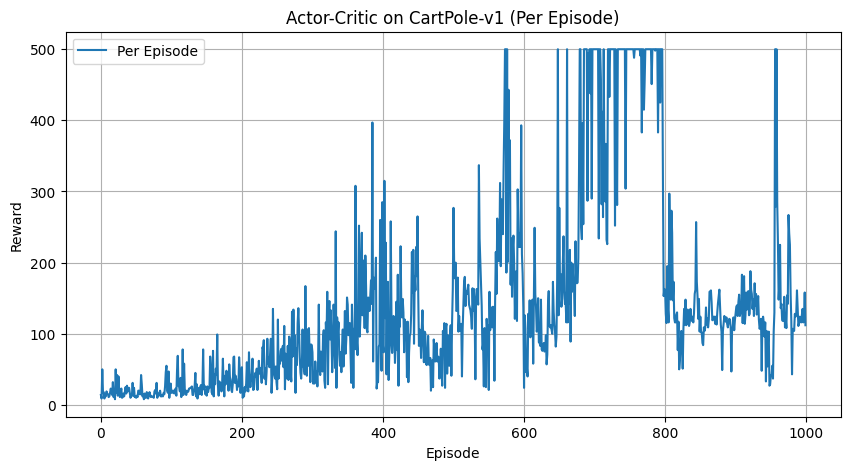

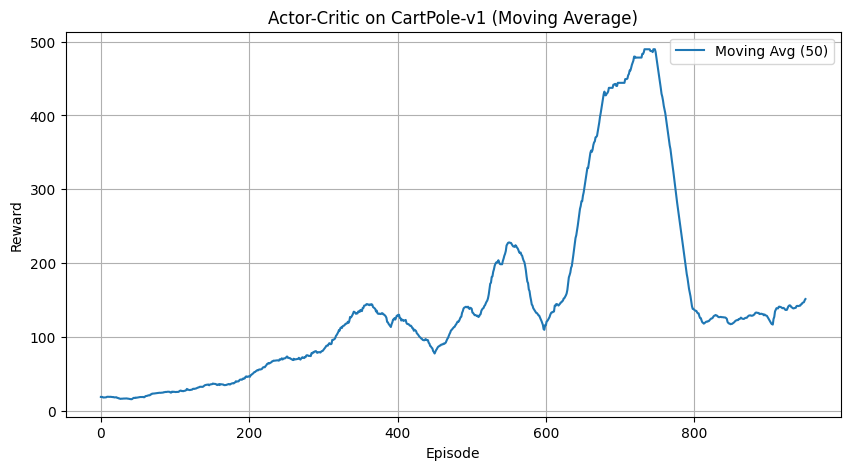

In [22]:
import numpy as np
import matplotlib.pyplot as plt

rewards_per_episode = train()

smoothed = np.convolve(
    rewards_per_episode,
    np.ones(50)/50,
    mode='valid'
)

# Plot 1: per-episode rewards
plt.figure(figsize=(10,5))
plt.plot(rewards_per_episode, label='Per Episode')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('Actor-Critic on CartPole-v1 (Per Episode)')
plt.grid(True)
plt.legend()
plt.show()

# Plot 2: moving average
plt.figure(figsize=(10,5))
plt.plot(smoothed, label='Moving Avg (50)')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('Actor-Critic on CartPole-v1 (Moving Average)')
plt.grid(True)
plt.legend()
plt.show()
